# DBSCAN: A Comprehensive Guide

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a clustering algorithm that groups together points that are closely packed together, while marking points in low-density regions as outliers.

In this notebook, we'll cover:
1. Basic concepts of DBSCAN
2. Data preparation and visualization
3. Model implementation from scratch
4. Using scikit-learn for DBSCAN
5. Parameter tuning and model evaluation

# Simple Explanation: What Does the Code Below Do?

Imagine you're looking at a city from above. You see dense neighborhoods, sparse suburbs, and isolated houses in the countryside. DBSCAN:
- **Core points**: Points with many neighbors within radius ε (downtown)
- **Border points**: Points near a core point but with few own neighbors (suburbs)
- **Noise points**: Points far from any cluster (isolated houses — outliers!)

Two key parameters:
- **eps (ε)**: The radius within which to search for neighbors.
- **min_samples**: Minimum points in the neighborhood to be a core point.

Key advantages over K-Means:
1. Doesn't require specifying K (number of clusters) in advance.
2. Can find clusters of arbitrary shapes (not just spherical).
3. Naturally identifies outliers/noise.

Here's what the code does:
1. Implements DBSCAN from scratch.
2. Demonstrates it on complex-shaped clusters (moons, circles).
3. Shows how to tune eps and min_samples using k-distance plots.

In short: DBSCAN finds clusters based on density — perfect for complex shapes and detecting outliers!

In [1]:
import os
import sys

venv_dir = 'ml_env'
if not os.path.exists(venv_dir):
    os.system(f'{sys.executable} -m venv {venv_dir}')
    print(f'Virtual environment created at {venv_dir}')
else:
    print(f'Virtual environment already exists at {venv_dir}')

pip_path = os.path.join(venv_dir, 'Scripts', 'pip')
if sys.platform == 'win32':
    pip_path += '.exe'

if os.path.exists(pip_path):
    os.system(f'"{pip_path}" install numpy pandas matplotlib seaborn scikit-learn')
    print('Required libraries installed.')
else:
    print('Could not find pip. Please check your Python installation.')

Virtual environment already exists at ml_env
Could not find pip. Please check your Python installation.


# 1. Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons, make_circles, make_blobs
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 2. Generating Sample Data

We'll use datasets with non-spherical shapes where K-Means fails but DBSCAN excels.

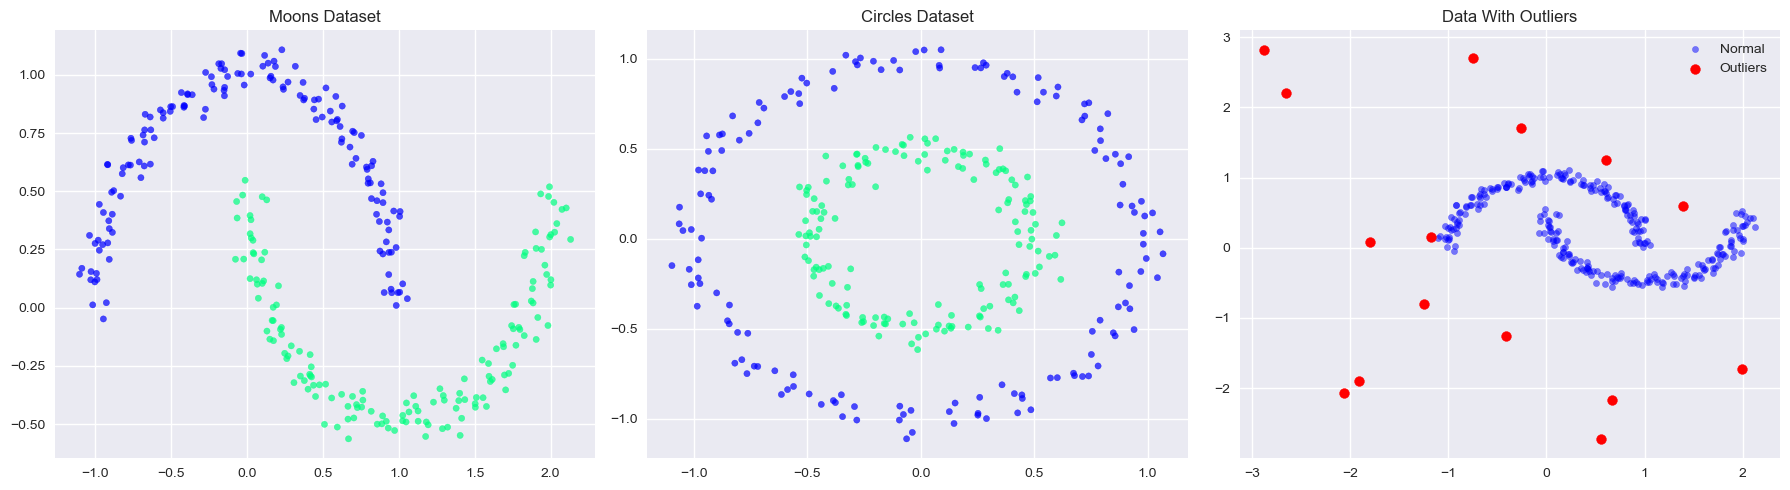

In [3]:
np.random.seed(42)

X_moons, y_moons = make_moons(n_samples=300, noise=0.05, random_state=42)
X_circles, y_circles = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)

# Add some outliers to the moons dataset
outliers = np.random.uniform(low=-3, high=3, size=(15, 2))
X_with_outliers = np.vstack([X_moons, outliers])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='winter', alpha=0.7, s=20)
axes[0].set_title('Moons Dataset')
axes[1].scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='winter', alpha=0.7, s=20)
axes[1].set_title('Circles Dataset')
axes[2].scatter(X_with_outliers[:300, 0], X_with_outliers[:300, 1], c='blue', alpha=0.5, s=20, label='Normal')
axes[2].scatter(X_with_outliers[300:, 0], X_with_outliers[300:, 1], c='red', s=50, label='Outliers', zorder=5)
axes[2].set_title('Data With Outliers')
axes[2].legend()

plt.tight_layout()
plt.show()

# 3. Implementing DBSCAN from Scratch

Algorithm:
1. For each point, find all neighbors within radius ε.
2. If >= min_samples neighbors → it's a **core point**.
3. Build clusters by expanding from core points.
4. Points not in any cluster → **noise** (label = -1).

Clusters found: 2
Noise points: 0


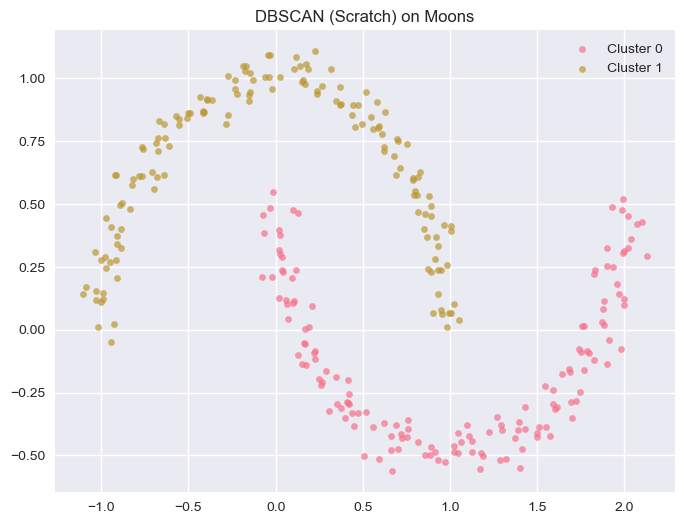

In [4]:
class DBSCANScratch:
    def __init__(self, eps=0.5, min_samples=5):
        self.eps = eps
        self.min_samples = min_samples
        self.labels = None

    def _neighbors(self, X, point_idx):
        dists = np.linalg.norm(X - X[point_idx], axis=1)
        return np.where(dists <= self.eps)[0].tolist()

    def fit_predict(self, X):
        n = len(X)
        self.labels = np.full(n, -1)  # -1 = noise
        cluster_id = 0

        for point_idx in range(n):
            if self.labels[point_idx] != -1:
                continue  # already processed

            neighbors = self._neighbors(X, point_idx)

            if len(neighbors) < self.min_samples:
                self.labels[point_idx] = -1  # noise
                continue

            # Core point — start new cluster
            self.labels[point_idx] = cluster_id
            seed_set = set(neighbors) - {point_idx}

            while seed_set:
                q = seed_set.pop()
                if self.labels[q] == -1:
                    self.labels[q] = cluster_id  # border point
                elif self.labels[q] != -1:
                    continue  # already in a cluster

                self.labels[q] = cluster_id
                q_neighbors = self._neighbors(X, q)
                if len(q_neighbors) >= self.min_samples:
                    seed_set |= set(q_neighbors)

            cluster_id += 1

        return self.labels

# Apply to moons
db_scratch = DBSCANScratch(eps=0.2, min_samples=5)
labels_scratch = db_scratch.fit_predict(X_moons)
n_clusters_scratch = len(set(labels_scratch)) - (1 if -1 in labels_scratch else 0)

print(f'Clusters found: {n_clusters_scratch}')
print(f'Noise points: {np.sum(labels_scratch == -1)}')

plt.figure(figsize=(8, 6))
unique_labels = set(labels_scratch)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
for label, color in zip(unique_labels, colors):
    if label == -1:
        plt.scatter(X_moons[labels_scratch == label, 0], X_moons[labels_scratch == label, 1],
                    c='red', marker='x', s=60, label='Noise')
    else:
        plt.scatter(X_moons[labels_scratch == label, 0], X_moons[labels_scratch == label, 1],
                    alpha=0.7, s=20, label=f'Cluster {label}')
plt.title('DBSCAN (Scratch) on Moons')
plt.legend()
plt.show()

# 4. Using Scikit-learn's DBSCAN — DBSCAN vs K-Means Comparison

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


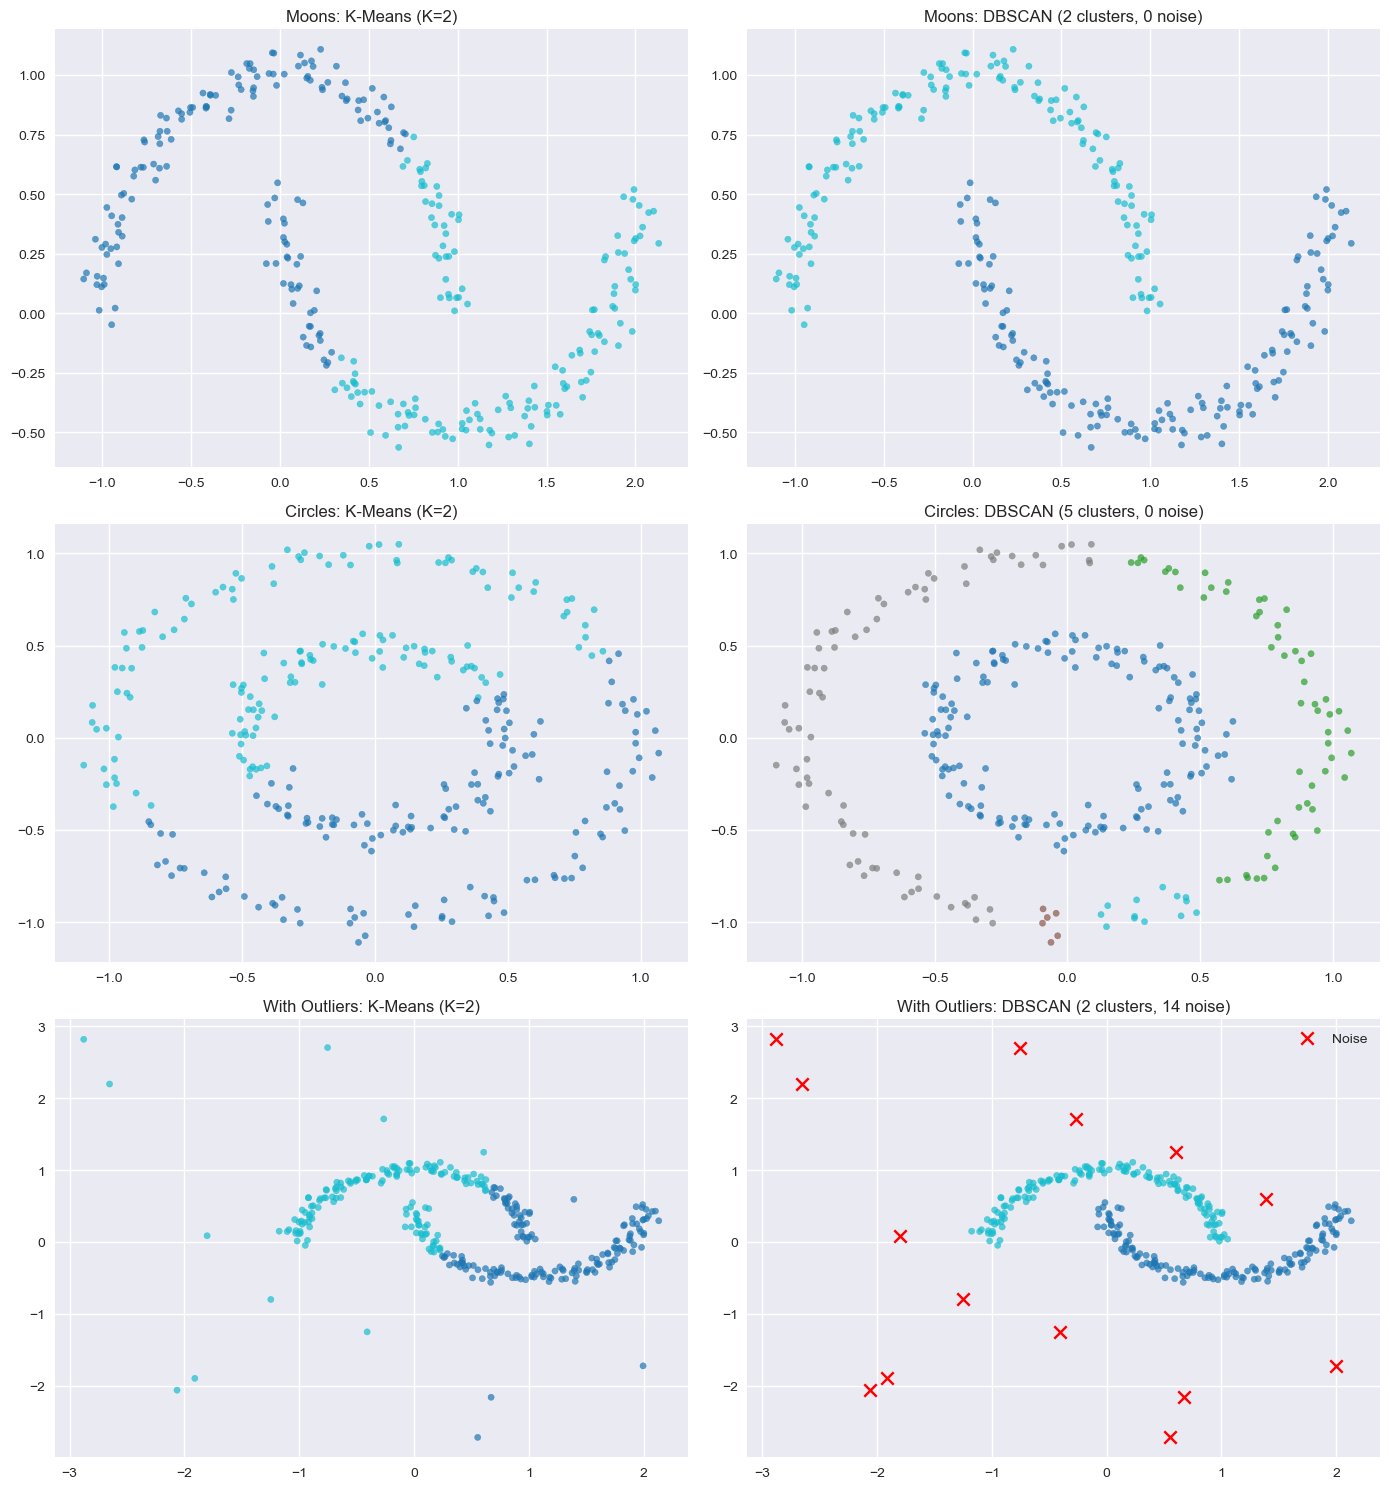

In [5]:
datasets = [
    ('Moons', X_moons, 0.2, 5),
    ('Circles', X_circles, 0.15, 5),
    ('With Outliers', X_with_outliers, 0.3, 5)
]

fig, axes = plt.subplots(3, 2, figsize=(14, 15))

for row, (name, X_data, eps, min_s) in enumerate(datasets):
    # K-Means
    km = KMeans(n_clusters=2, n_init=10, random_state=42)
    labels_km = km.fit_predict(X_data)
    axes[row, 0].scatter(X_data[:, 0], X_data[:, 1], c=labels_km, cmap='tab10', alpha=0.7, s=20)
    axes[row, 0].set_title(f'{name}: K-Means (K=2)')

    # DBSCAN
    db = DBSCAN(eps=eps, min_samples=min_s)
    labels_db = db.fit_predict(X_data)
    n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    n_noise = np.sum(labels_db == -1)

    # Plot: color noise points differently
    mask_noise = labels_db == -1
    axes[row, 1].scatter(X_data[~mask_noise, 0], X_data[~mask_noise, 1],
                          c=labels_db[~mask_noise], cmap='tab10', alpha=0.7, s=20)
    axes[row, 1].scatter(X_data[mask_noise, 0], X_data[mask_noise, 1],
                          c='red', marker='x', s=80, label='Noise')
    axes[row, 1].set_title(f'{name}: DBSCAN ({n_clusters} clusters, {n_noise} noise)')
    if n_noise > 0:
        axes[row, 1].legend()

plt.tight_layout()
plt.show()

# 5. Tuning eps — K-Distance Plot

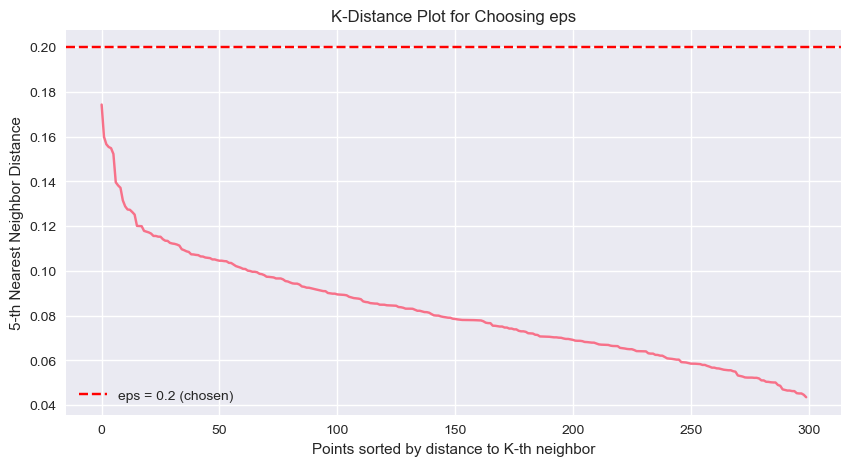


Key Insights:
- Look for the "elbow" in the k-distance plot → that's a good eps value.
- Small eps → many noise points; large eps → few clusters, fewer noise points.
- DBSCAN excels at non-spherical clusters and outlier detection.
- Struggles with clusters of varying density.


In [6]:
# K-Distance Plot: helps choose eps
# Sort the k-th nearest neighbor distances — look for the "elbow"
min_samples = 5
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_moons)
distances, _ = nbrs.kneighbors(X_moons)
kth_distances = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(kth_distances)
plt.axhline(y=0.2, color='red', linestyle='--', label='eps = 0.2 (chosen)')
plt.xlabel('Points sorted by distance to K-th neighbor')
plt.ylabel(f'{min_samples}-th Nearest Neighbor Distance')
plt.title('K-Distance Plot for Choosing eps')
plt.legend()
plt.grid(True)
plt.show()

print('\nKey Insights:')
print('- Look for the "elbow" in the k-distance plot → that\'s a good eps value.')
print('- Small eps → many noise points; large eps → few clusters, fewer noise points.')
print('- DBSCAN excels at non-spherical clusters and outlier detection.')
print('- Struggles with clusters of varying density.')

# Conclusions and Key Takeaways
Density-Based Spatial Clustering of Applications with Noise (DBSCAN) is a powerful clustering algorithm that targets clusters of varying shapes based on data density, ignoring areas of low data point density.
- **Shape Agnostic**: Unlike K-Means, which assumes spherical clusters, DBSCAN can find clusters of completely arbitrary, non-linear shapes (like concentric rings).
- **Noise Tolerant**: It natively identifies and isolates outlier anomalies as "noise", whereas K-means forces every point into a cluster.
- **No K Required**: You do not need to specify the number of clusters a priori.

# Pros and Cons
**Pros:**
- Doesn't require specifying the number of clusters in advance.
- Can discover arbitrarily shaped clusters.
- Robust to outliers, separating them cleanly into a noise category (-1 label).

**Cons:**
- Struggles immensely when clusters have varying densities; a single `eps` and `min_samples` combo cannot adequately capture dense and sparse clusters simultaneously.
- Extremely sensitive to the choice of its two hyperparameters (`eps` and `min_samples`).
- Performance degrades severely in high-dimensional spaces (Curse of Dimensionality) due to reliance on distance metrics.

# 15 Interview Questions and Answers

1. **What does DBSCAN stand for?**
   *Answer*: Density-Based Spatial Clustering of Applications with Noise.

2. **How does DBSCAN fundamentally define a "cluster"?**
   *Answer*: As a contiguous region of high point density, separated from other such regions by areas of low point density.

3. **What are the two key hyperparameters in DBSCAN?**
   *Answer*: `eps` (epsilon), which is the maximum distance between two points for them to be considered neighbors, and `min_samples`, which is the minimum number of neighbors a point must have within `eps` to be considered a core point.

4. **What is a "Core Point"?**
   *Answer*: A data point that has at least `min_samples` points (including itself) within its `eps` radius. It forms the dense foundation of a cluster.

5. **What is a "Border Point"?**
   *Answer*: A point that does not have enough neighbors to be a core point, but falls within the `eps` radius of an existing core point. It makes up the outer edge of a cluster.

6. **What is a "Noise Point" (Outlier)?**
   *Answer*: A point that is neither a core point nor a border point. It is strictly isolated in a low-density region and assigned a cluster label of -1 in scikit-learn.

7. **How does DBSCAN differ from K-Means?**
   *Answer*: K-Means partitions data into a preset 'K' spherical clusters and assigns every outlier to a cluster. DBSCAN determines the number of clusters automatically based on density, can find arbitrary shapes, and isolates outliers as noise.

8. **How does DBSCAN struggle with varying density?**
   *Answer*: Because `eps` is fixed globally. If you set `eps` small enough to separate thick clusters, sparse clusters will be incorrectly labeled as noise. If you set `eps` large enough to include sparse clusters, dense clusters will blur together into one massive cluster.

9. **What is OPTICS, and how does it relate to DBSCAN?**
   *Answer*: Ordering Points To Identify the Clustering Structure (OPTICS) is an extension of DBSCAN that addresses the varying density problem by sorting points based on their reachability distance, essentially allowing for a variable `eps`.

10. **How do you choose an appropriate value for `eps`?**
    *Answer*: By plotting a K-distance graph. You calculate the distance to the k-th nearest neighbor (where k = min_samples) for every point, sort them descending, and look for an "elbow" or sharp curve in the graph to find the optimal `eps`.

11. **How do you typically choose `min_samples`?**
    *Answer*: A general rule of thumb is `min_samples >= Dimensions + 1`. For noisy datasets or very large datasets, a higher value is preferred to enforce stricter density requirements.

12. **Is scaling necessary for DBSCAN?**
    *Answer*: Yes, absolutely. Because it relies heavily on distance metrics (usually Euclidean) to define the `eps` neighborhood, unscaled features will heavily skew the distance calculation.

13. **What is the time complexity of DBSCAN?**
    *Answer*: With a spatial indexing structure (like an R-tree or KD-tree), it's roughly O(N log N). However, in high dimensions where such trees degrade, or with a naive brute-force implementation, it degrades to O(N^2).

14. **Is DBSCAN completely deterministic?**
    *Answer*: No. While Core and Noise points are deterministic given the data and parameters, Border points that fall within the `eps` radius of core points from *two different clusters* will be assigned to whichever cluster the algorithm processes first.

15. **What distance metric is usually best for DBSCAN on text/document data?**
    *Answer*: Cosine distance or Jaccard similarity. Standard Euclidean distance fails badly in exceedingly high-dimensional sparse spaces like text bag-of-words.
